<img src="https://raw.githubusercontent.com/egiuse25/APS/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Emilia Giusepponi

## Consigna  
En esta tarea semanal analizaremos un fenómeno muy particular que se da al calcular la DFT, el efecto de desparramo espectral.  

Luego, haremos el siguiente experimento:

Senoidal de frecuencia $f_0 = k_0 ∗ f_s/N = k0 . Δf$ potencia normalizada, es decir energía (o varianza) unitaria

Se pide:

$a)$ Sea k0

• N/4
 
• N/4 + 0.25
 
• N/4 + 0.5
 
Notar que a cada senoidal se le agrega una pequeña desintonía respecto a  $Δf$
. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

$b)$ Verificar la potencia unitaria de cada PSD, puede usar la identidad de Parseval. En base a la teoría estudiada. Discuta la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia. 

$c)$ Repetir el experimento mediante la técnica de zero padding. Dicha técnica consiste en agregar ceros al final de la señal para aumentar $Δf$ de forma ficticia. Probar agregando un vector de 9*N ceros al final. Discuta los resultados obtenidos.

Bonus
💎 Calcule la respuesta en frecuencia de los sistemas LTI de la TS2.

## Desarrollo 
### Definición de función seno
Para empezar, se comienza definiendo la función seno dada por:
$$x(t) = DC + A \cdot \sin(2\pi \cdot f \cdot t + \phi)$$
Siendo en el código:

• Señal senoidal ($x(t)$) = `xx`.

• Desplazamiento en el eje Y (Valor medio) ($DC$) = `dc`.

• Amplitud ($A$) = `vmax`.

• Frecuencia angular ($2\pi \cdot f $) = `2 * np.pi * ff`.

• Fase ($\phi$) = `ph`.

La resolución espectral es lo que define el espacio entre frecuencias en la visualización de una señal discreta. Se define como:$$\Delta f = \frac{f_s}{N}$$Siendo $f_s$ la frecuencia de muestreo y $N$ la cantidad de muestras.


In [25]:
import numpy as np

#DEFINICION DE FUNCION SENO
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

vmax = np.sqrt(2) # POTENCIA DE 1 W
dc=0
ph= 0 
N= 1000
fs= N
df= fs/N # RESOLUCION ESPECTRAL

Posteriormente, defino las funciones senoidales con y sin desintonía:

In [26]:
# DESINTONIAS
k0_1 = N/4
k0_2 = (N/4) + 0.25
k0_3 = (N/4) + 0.5

# FRECUENCIAS
ff1 = k0_1 * df
ff2 = k0_2 * df
ff3 = k0_3 * df

# SEÑALES 
tt,xx1 = mi_funcion_sen(vmax, dc,ff1,ph,N,fs)
tt,xx2 = mi_funcion_sen(vmax, dc,ff2,ph,N,fs)
tt,xx3= mi_funcion_sen(vmax, dc,ff3,ph,N,fs)

Calculo la Transformada de Fourier junto con su espectro de potencia para cada una de las funciones previamente generadas. 

In [27]:
XX1 = np.fft.fft(xx1) / N 
XXmod = np.abs(XX1) # MODULO
XXmod_cuadrado = XXmod**2 *2 # MODULO AL CUADRADO -> ESPECTRO POTENCIA
XXesp_db = 10 * np.log10(XXmod_cuadrado + 1e-12 ) # ESPECTRO POTENCIA 

XX2 = np.fft.fft(xx2) / N
XXmod2 = np.abs(XX2) # MODULO
XXmod_cuadrado2 = XXmod2**2 *2 # MODULO AL CUADRADO -> ESPECTRO POTENCIA
XXesp_db2 = 10 * np.log10(XXmod_cuadrado2 + 1e-12 ) # ESPECTRO POTENCIA 

XX3 = np.fft.fft(xx3) / N
XXmod3 = np.abs(XX3) # MODULO
XXmod_cuadrado3 = XXmod3**2 *2 # MODULO AL CUADRADO -> ESPECTRO POTENCIA
XXesp_db3 = 10 * np.log10(XXmod_cuadrado3 + 1e-12 ) # ESPECTRO POTENCIA 

XX1_mitad = XXesp_db[0:(N//2)] # PARA GRAFICAR LA MITAD 
XX2_mitad = XXesp_db2[0:(N//2)]
XX3_mitad = XXesp_db3[0:(N//2)]

### a) Graficar densidades espectrales


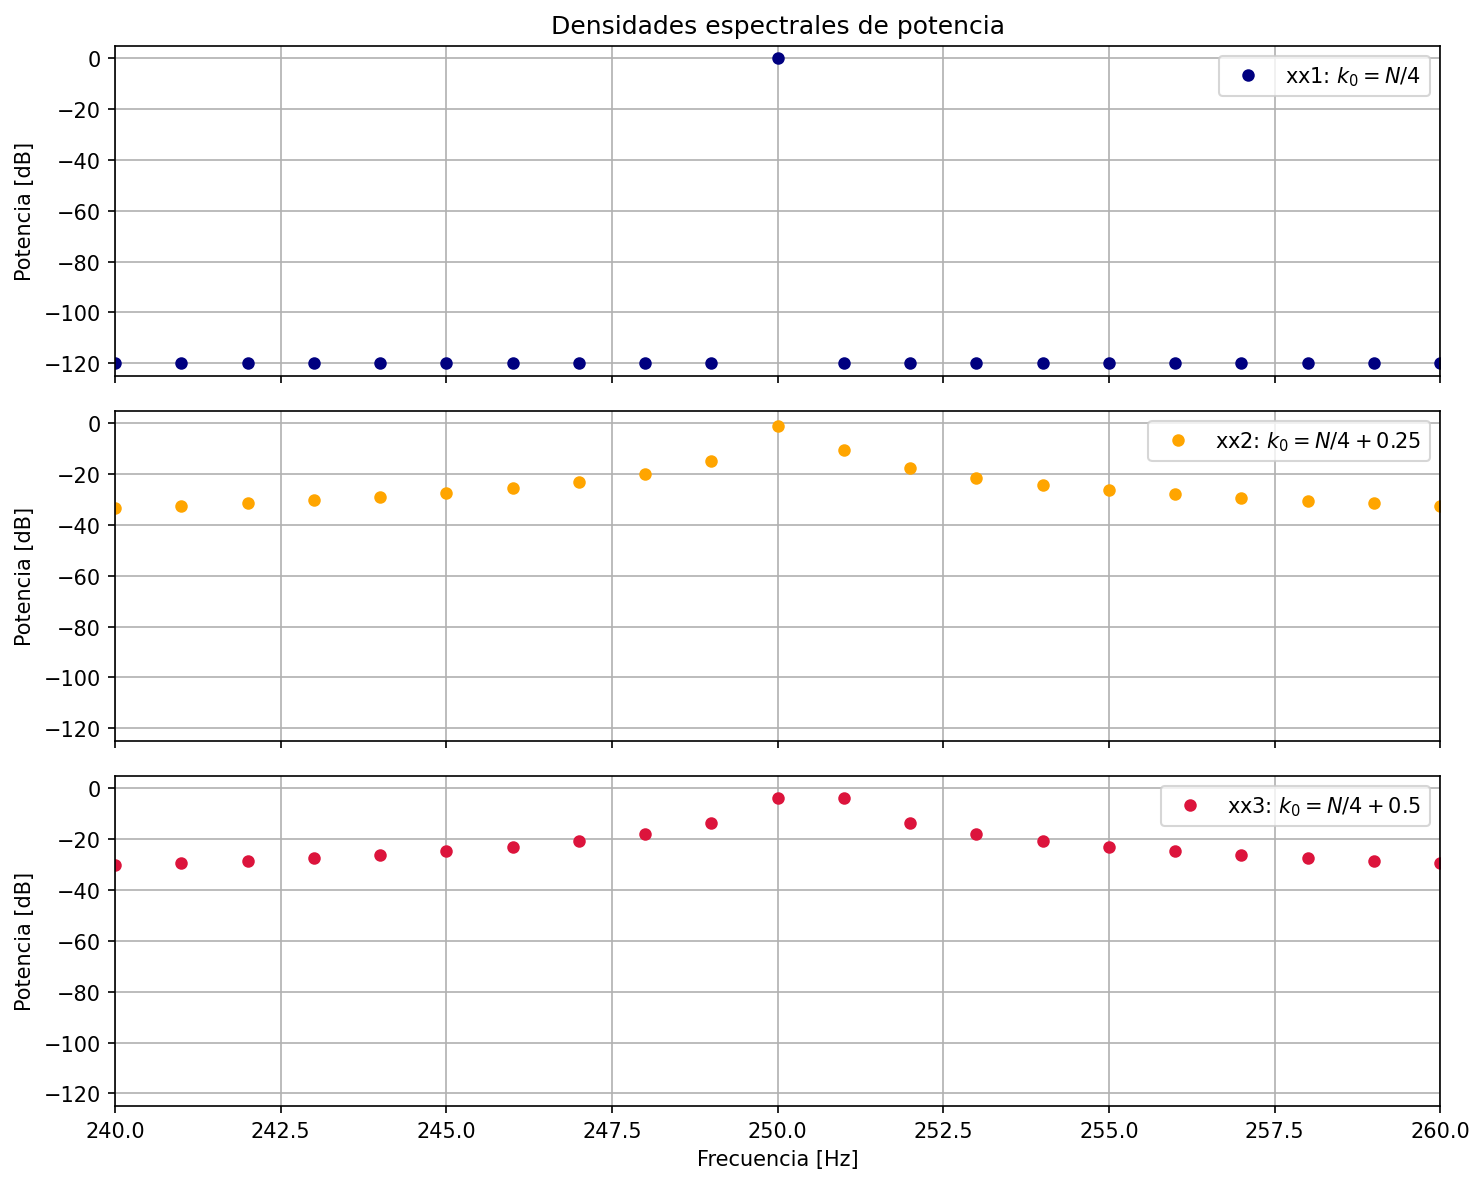

In [28]:
import matplotlib.pyplot as plt

eje_f = np.arange(0, N//2) * df # EJE DE FRECUENCIAS 
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True, dpi=150)

axs[0].plot(eje_f, XX1_mitad, 'o', color='navy', markersize=5, label='xx1: $k_0 = N/4$')
axs[0].set_title('Densidades espectrales de potencia')
axs[0].set_ylabel('Potencia [dB]')
axs[0].set_ylim(-125, 5)
axs[0].grid(True)
axs[0].legend(loc='upper right')

axs[1].plot(eje_f, XX2_mitad, 'o', color='orange', markersize=5, label='xx2: $k_0 = N/4 + 0.25$')
axs[1].set_ylabel('Potencia [dB]')
axs[1].set_ylim(-125, 5)
axs[1].grid(True)
axs[1].legend(loc='upper right')

axs[2].plot(eje_f, XX3_mitad, 'o', color='crimson', markersize=5, label='xx3: $k_0 = N/4 + 0.5$')
axs[2].set_xlabel('Frecuencia [Hz]')
axs[2].set_ylabel('Potencia [dB]')
axs[2].set_ylim(-125, 5)
axs[2].grid(True)
axs[2].legend(loc='upper right')

plt.xlim(240, 260) 
plt.tight_layout()
plt.show()

Se puede observar como para la primera función senoidal sin desintonía se observa un único bin, en el cual se concentra toda su energía ya que la frecuencia coincide exactamente con un múltiplo entero de la resolución espectral. Para el resto de los casos, a medida que se aumenta la desintonía, la frecuencia de la señal deja de coincidir con un múltiplo entero de la resolución espectral y se genera un desparramo espectral. 

Esto es debido a que la DFT asume que la señal es periódica de período N. Como la frecuencia no es múltiplo entero de la resolución espectral, al propagarse la señal periódicamente se genera una discontinuidad que hace que la energía de ese bin se propague hacia sus costados.

### b) Teorema de Parseval
El Teorema de Parseval establece que la potencia total calculada en el dominio del tiempo debe ser exactamente igual a la energía total calculada en el dominio de la frecuencia.

En el dominio del tiempo se calcula de la siguiente manera: 

$$P = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2$$

En el de la frecuencia:$$P = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$

In [29]:
# POTENCIA EN EL TIEMPO
pot_tiempo_1 = np.mean(xx1**2)
pot_tiempo_2 = np.mean(xx2**2)
pot_tiempo_3 = np.mean(xx3**2)

# POTENCIA EN FRECUENCIA 
pot_frec_1 = np.sum(np.abs(XX1)**2)
pot_frec_2 = np.sum(np.abs(XX2)**2)
pot_frec_3 = np.sum(np.abs(XX3)**2)

print(f"Potencia de xx1 (Sin desintonía):   Tiempo = {pot_tiempo_1:.3f} W | Frecuencia = {pot_frec_1:.3f} W")
print(f"Potencia de xx2 (+0.25 desintonía): Tiempo = {pot_tiempo_2:.3f} W | Frecuencia = {pot_frec_2:.3f} W")
print(f"Potencia de xx3 (+0.50 desintonía): Tiempo = {pot_tiempo_3:.3f} W | Frecuencia = {pot_frec_3:.3f} W")

Potencia de xx1 (Sin desintonía):   Tiempo = 1.000 W | Frecuencia = 1.000 W
Potencia de xx2 (+0.25 desintonía): Tiempo = 0.999 W | Frecuencia = 0.999 W
Potencia de xx3 (+0.50 desintonía): Tiempo = 1.000 W | Frecuencia = 1.000 W



Mediante los resultados obtenidos analíticamente, aplicando la identidad de Parseval, se observa como la potencia se mantiene igual en todos los casos sin importar su desintonía, siendo de 1W. Si bien cada uno de sus espectros se ven distintos porque ocurre el desparramo espectral, la energía total del sistema se conserva.

### b) Técnica de Zero Padding


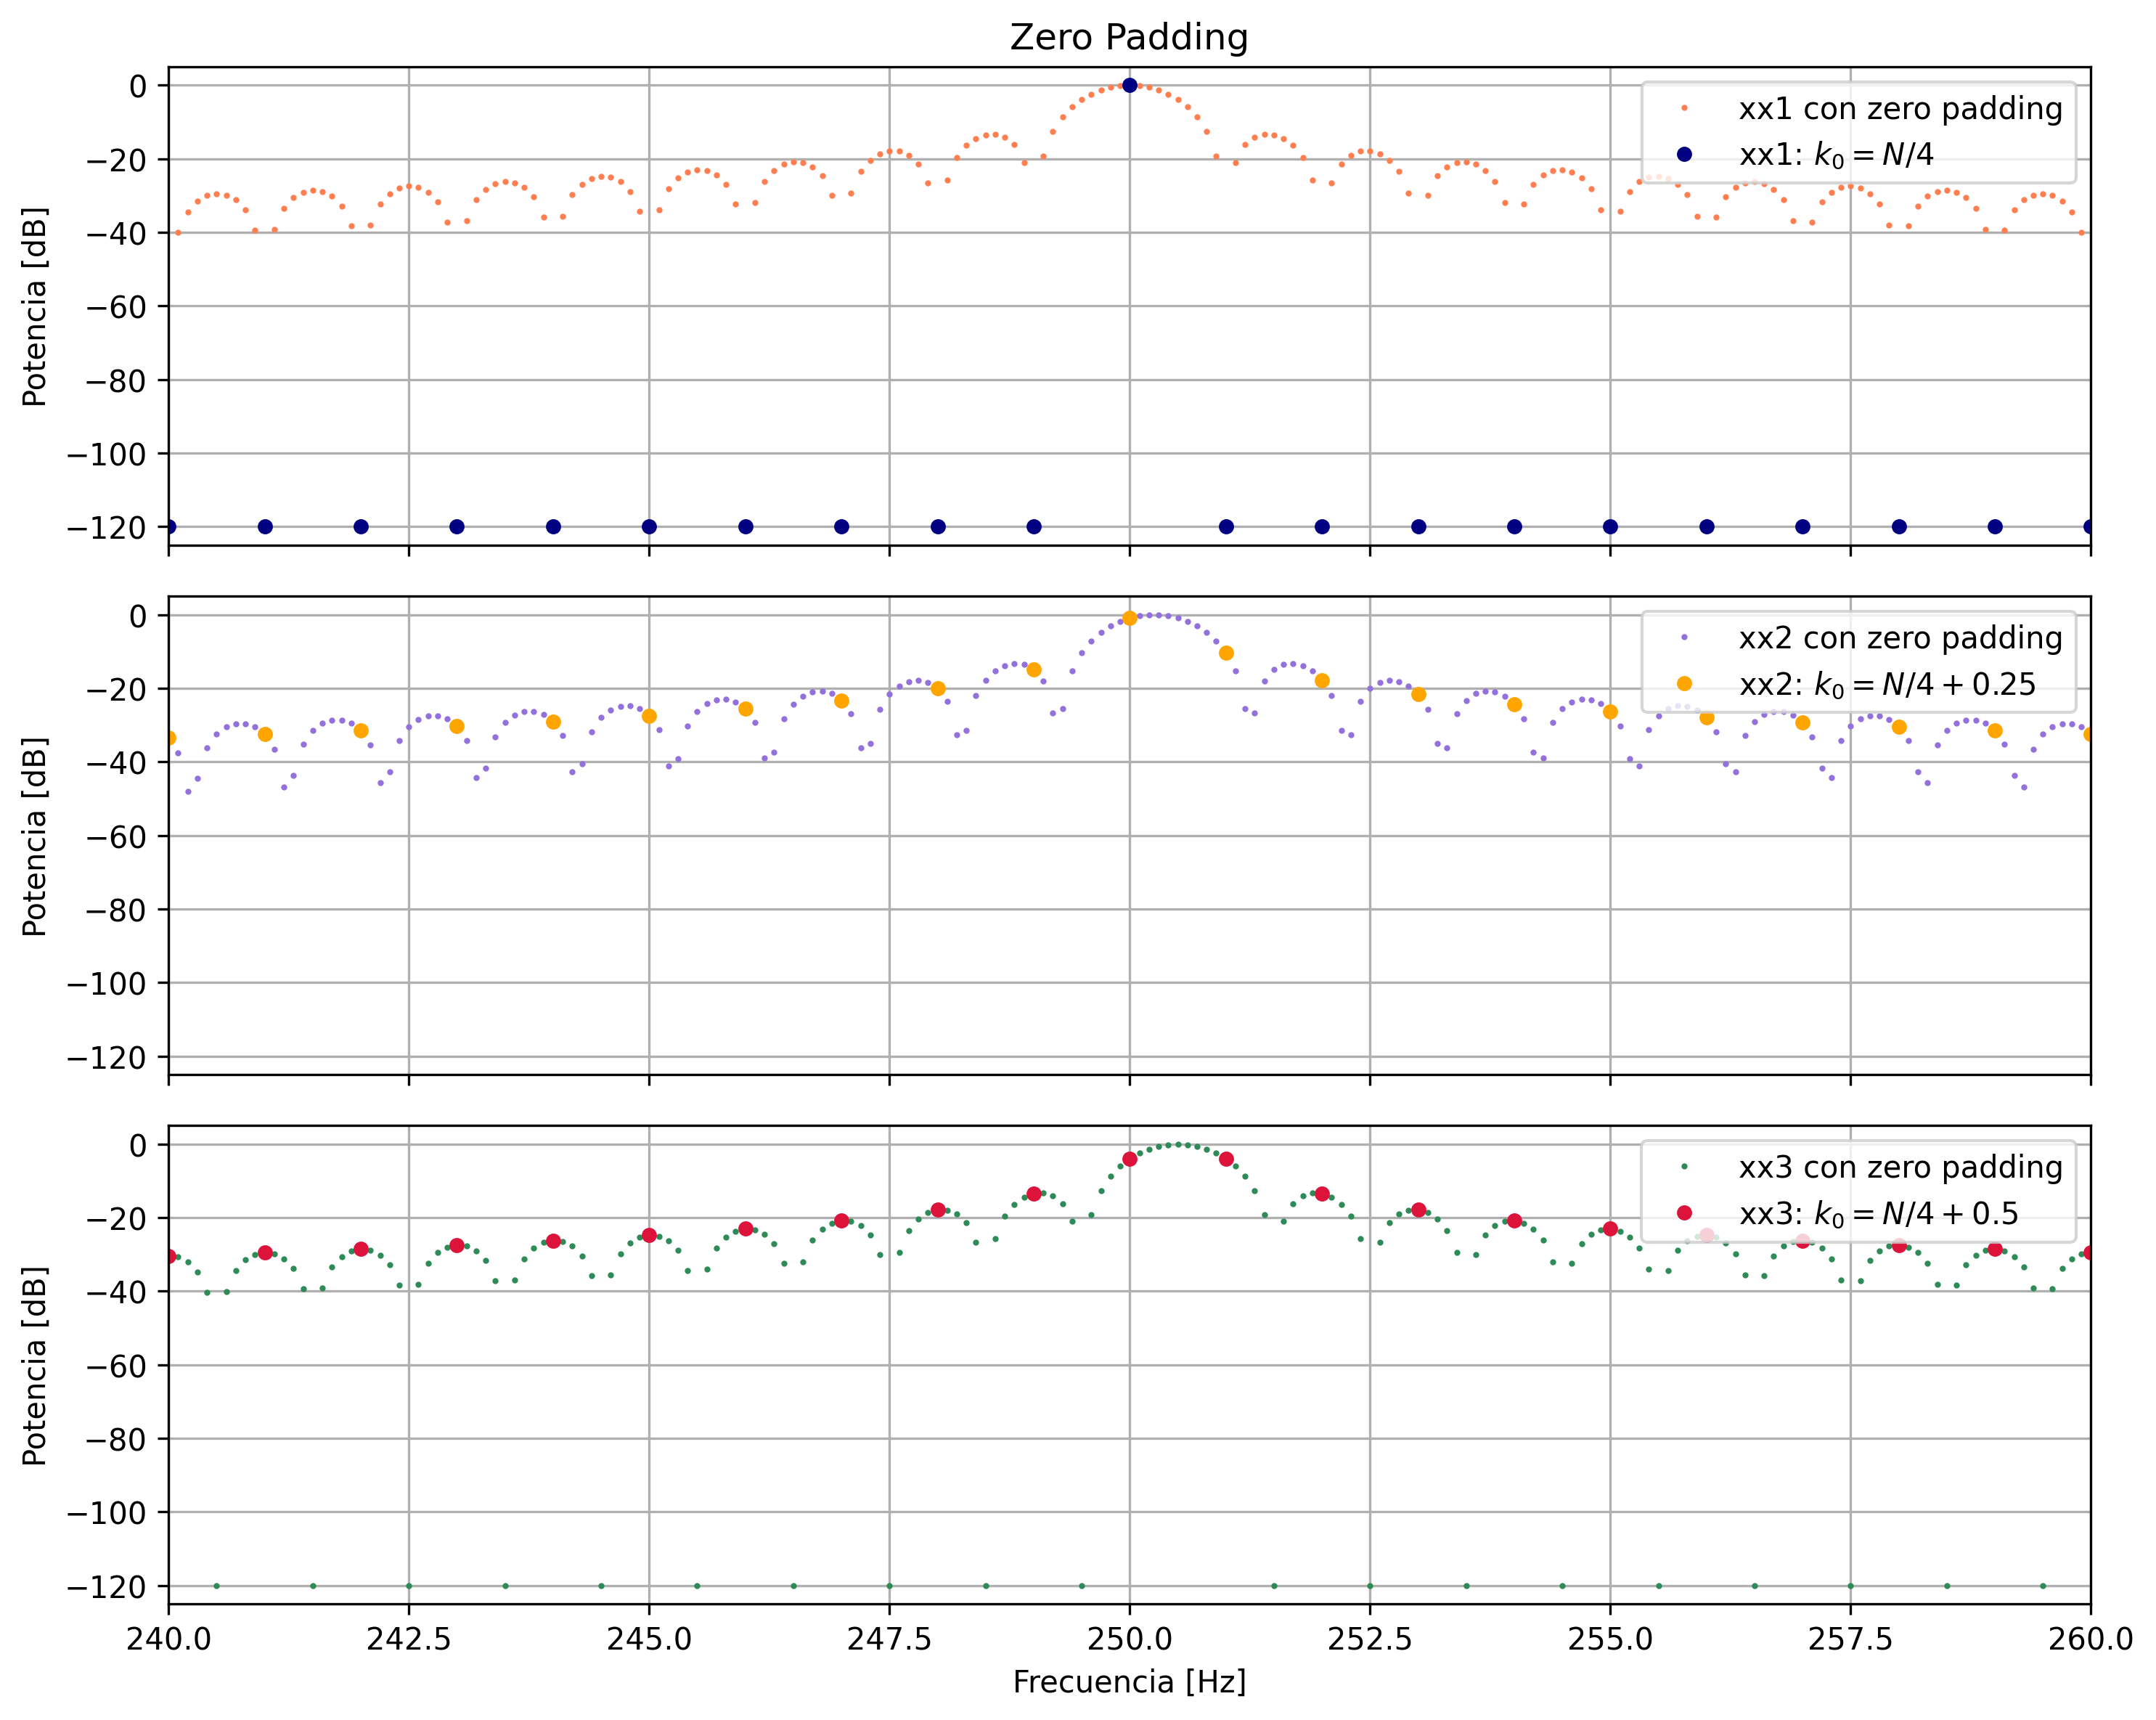

In [30]:
zz = np.zeros(9 * N) # VECTOR DE CEROS 

# SEÑAL ORIGINAL CON LOS CEROS
xx1_zp = np.concatenate((xx1, zz), axis=None)
xx2_zp = np.concatenate((xx2, zz), axis=None)
xx3_zp = np.concatenate((xx3, zz), axis=None)

N_zp = 10 * N # NUEVO LARGO TOTAL
df_zp = fs / N_zp # NUEVO DELTA F
eje_f_zp = np.arange(0, N_zp//2) * df_zp

XX1_zp = np.fft.fft(xx1_zp)
XXmod_zp = np.abs(XX1_zp) / N 
XXmod_cuadrado_zp = (XXmod_zp**2) * 2 
XXesp_db_zp = 10 * np.log10(XXmod_cuadrado_zp + 1e-12)

XX2_zp = np.fft.fft(xx2_zp)
XXmod2_zp = np.abs(XX2_zp) / N 
XXmod_cuadrado2_zp = (XXmod2_zp**2) * 2
XXesp_db2_zp = 10 * np.log10(XXmod_cuadrado2_zp + 1e-12)

XX3_zp = np.fft.fft(xx3_zp)
XXmod3_zp = np.abs(XX3_zp) / N 
XXmod_cuadrado3_zp = (XXmod3_zp**2) * 2
XXesp_db3_zp = 10 * np.log10(XXmod_cuadrado3_zp + 1e-12)

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True, dpi=300)

axs[0].plot(eje_f_zp, XXesp_db_zp[0:N_zp//2], 'o', color='coral', markersize = 1, label='xx1 con zero padding')
axs[0].plot(eje_f, XX1_mitad, 'o', color='navy', markersize=4, label='xx1: $k_0 = N/4$')
axs[0].set_title('Zero Padding')
axs[0].set_ylabel('Potencia [dB]')
axs[0].set_ylim(-125, 5)
axs[0].grid(True)
axs[0].legend(loc='upper right')

axs[1].plot(eje_f_zp, XXesp_db2_zp[0:N_zp//2], 'o', color='mediumpurple',  markersize = 1, label='xx2 con zero padding')
axs[1].plot(eje_f, XX2_mitad, 'o', color='orange', markersize=4, label='xx2: $k_0 = N/4 + 0.25$')
axs[1].set_ylabel('Potencia [dB]')
axs[1].set_ylim(-125, 5)
axs[1].grid(True)
axs[1].legend(loc='upper right')

axs[2].plot(eje_f_zp, XXesp_db3_zp[0:N_zp//2], 'o', color='seagreen',  markersize = 1, label='xx3 con zero padding')
axs[2].plot(eje_f, XX3_mitad, 'o', color='crimson', markersize=4, label='xx3: $k_0 = N/4 + 0.5$')
axs[2].set_xlabel('Frecuencia [Hz]')
axs[2].set_ylabel('Potencia [dB]')
axs[2].set_ylim(-125, 5)
axs[2].grid(True)
axs[2].legend(loc='upper right')

plt.xlim(240, 260)
plt.tight_layout()
plt.show()

El espaciamiento entre los puntos de la DFT pasó de ser $Δf_{original} = 1$ $Hz$ a $Δf_{zero-padding} = 0.1$ $Hz$ debido a que la cantidad de muestras pasó de $N_{original} = 1000$ a $N_{zero-padding} = 10000$. Si bien el Zero Padding no agrega nueva información a la señal original y la resolución espectral real se mantiene intacta debido a que está determinada por la duración original de la señal, la distancia entre las frecuencias disminuyó y, en consecuencia, mejoró la visualización espectral debido a que ahora hay más puntos visibles dentro de la función y esto justifica los pocos puntos que se ven de la función original en comparación con la que se le aplicó el efecto. 

Además, se puede observar como en cada caso se muestra una forma tipo sinc, lo cual se debe a que la señal está implícitamente multiplicada por una ventana rectangular en el tiempo. 

## Conclusión

A partir de los resultados obtenidos se pudo analizar el fenómeno de desparramo espectral generado por frecuencias que no son múltiplos enteros de la resolución espectral, observándose cómo la energía asociada a ese bin se desparrama hacia sus bins adyacentes. 

A pesar de que en las funciones senoidales con distintas desintonías se observó de manera gráfica el fenómeno de desparramo espectral, se demostró numéricamente por la identidad de Parseval como la energía total de la señal se conserva. 

Por último, se le aplicó la técnica de zero padding a las funciones dadas. En este ultimo inciso se concluyó que si bien el agregado de ceros no mejora la resolución espectral real, sí disminuye el espacio entre los bins, permitiendo observar una mejor visualización del espectro continuo. 